In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------------------
# 1. SET UP AND LOAD THE DATA
# -------------------------------------------------------------------------
# Set visual style for plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Load the advertising dataset
# Ensure 'advertising.csv' is in your current working directory
if not os.path.exists("advertising.csv"):
    raise FileNotFoundError("Please ensure 'advertising.csv' is in the same folder as this script.")

df = pd.read_csv("advertising.csv")

print("==================================================")
# Check for an index column often named 'Unnamed: 0' and drop it if present
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("🤖 Cleaned up unnecessary index column.")

print("📊 Dataset successfully loaded!")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("==================================================\n")

📊 Dataset successfully loaded!
Dataset Shape: 200 rows, 4 columns



In [2]:
# 2. STATISTICAL SUMMARIES & DATA HEALTH CHECK
# -------------------------------------------------------------------------
print("--- [STEP 1] Data Information Summary ---")
df.info()
print("\n--- [STEP 2] Missing Values Count ---")
missing_values = df.isnull().sum()
print(missing_values)

print("\n--- [STEP 3] Descriptive Statistics ---")
stats_summary = df.describe()
print(stats_summary)
print("==================================================\n")

--- [STEP 1] Data Information Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB

--- [STEP 2] Missing Values Count ---
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

--- [STEP 3] Descriptive Statistics ---
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000  

🖼️ Generating Distribution and Feature Plots...


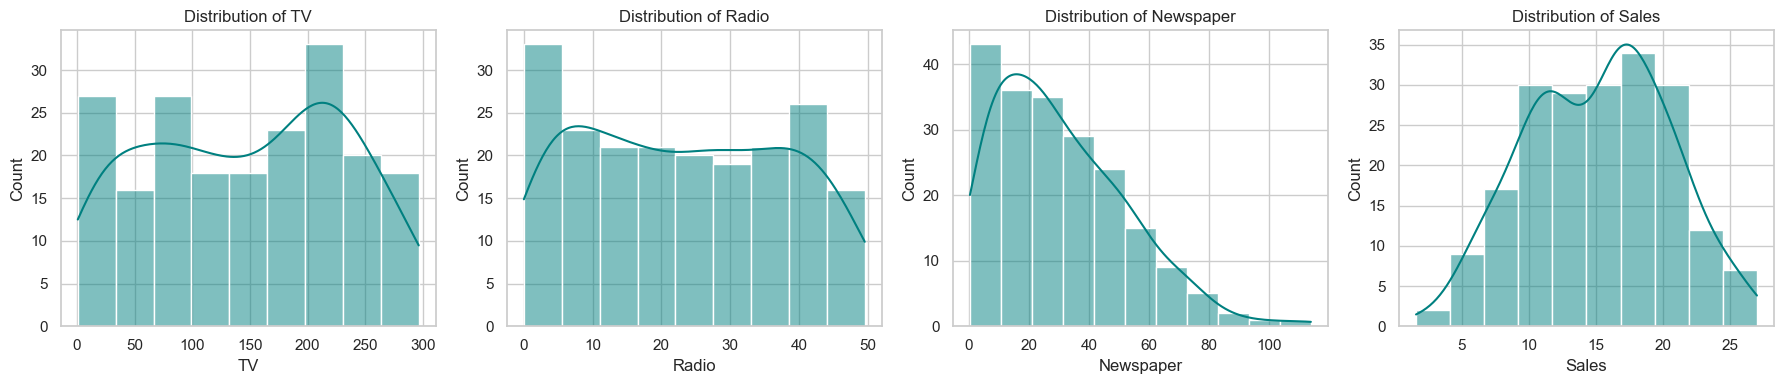

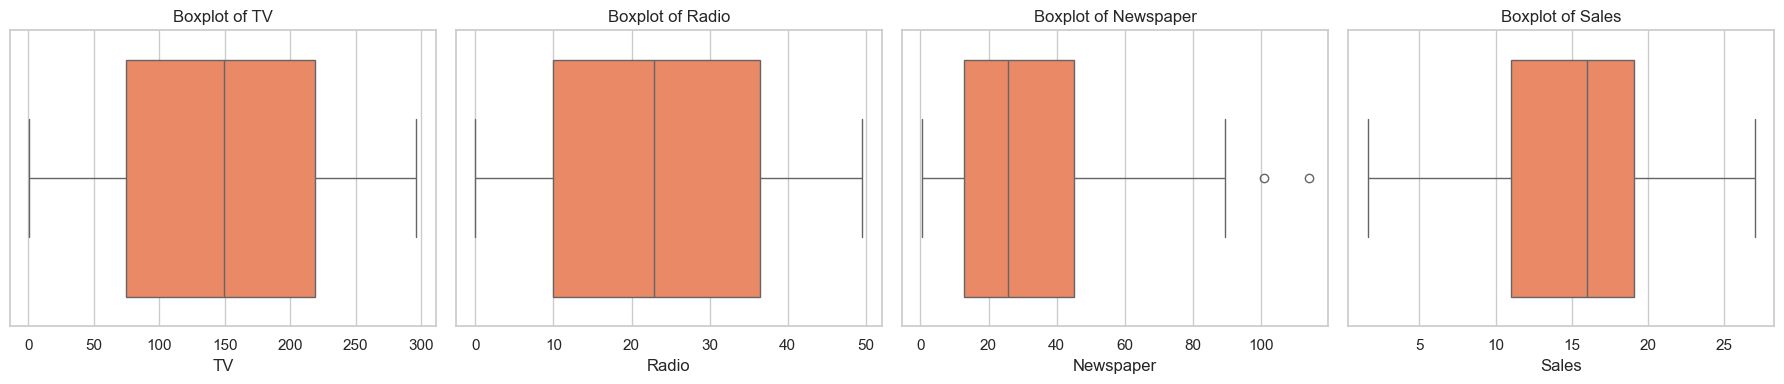

In [4]:
#3. VISUALIZATIONS (Distribution & Outliers)

print("🖼️ Generating Distribution and Feature Plots...")

# Plot 1: Feature Distributions (Histograms)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
features = df.columns

for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=300)
plt.show()

# Plot 2: Outlier Detection (Boxplots)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, col in enumerate(features):
    sns.boxplot(x=df[col], ax=axes[i], color='coral')
    axes[i].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.savefig('eda_outliers.png', dpi=300)
plt.show()

🔗 Analyzing Correlations...

--- [STEP 4] Correlation with Sales ---
Sales        1.000000
TV           0.901208
Radio        0.349631
Newspaper    0.157960
Name: Sales, dtype: float64


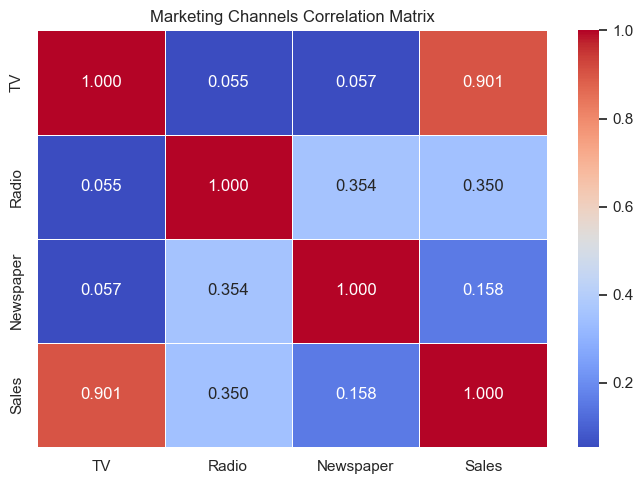

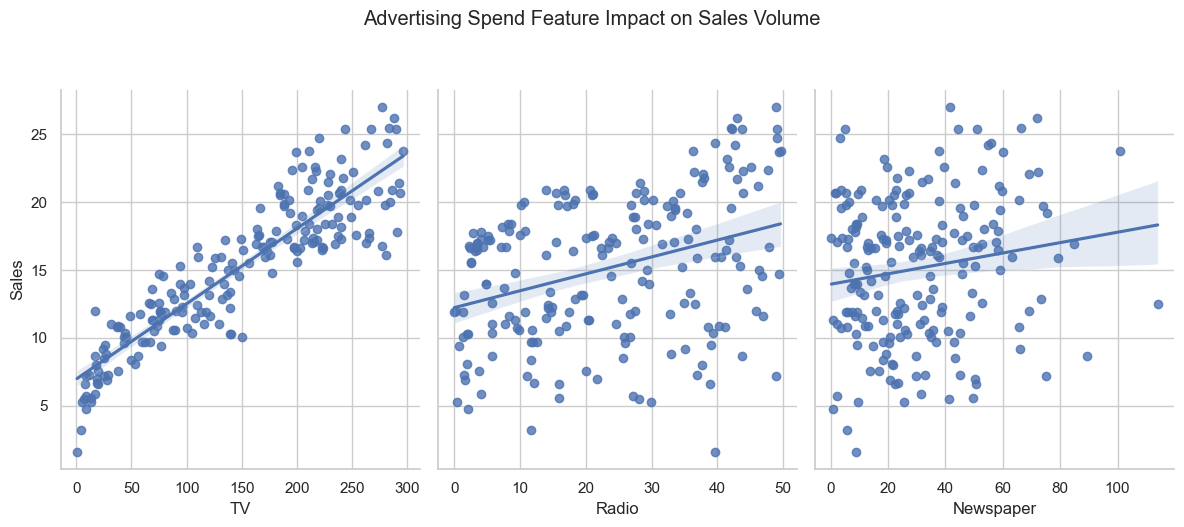

In [5]:
# 4. IDENTIFY CORRELATIONS & KEY INFLUENCING FACTORS

print("🔗 Analyzing Correlations...")

# Calculate linear relationships
corr_matrix = df.corr()
sales_correlation = corr_matrix['Sales'].sort_values(ascending=False)

print("\n--- [STEP 4] Correlation with Sales ---")
print(sales_correlation)

# Plot 3: Correlation Matrix Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title('Marketing Channels Correlation Matrix')
plt.tight_layout()
plt.savefig('eda_correlation_matrix.png', dpi=300)
plt.show()

# Plot 4: Pairwise Scatter Plots showing regression trends against Sales
sns.pairplot(df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales', height=5, aspect=0.8, kind='reg')
plt.suptitle("Advertising Spend Feature Impact on Sales Volume", y=1.05)
plt.tight_layout()
plt.savefig('eda_feature_trends.png', dpi=300)
plt.show()


🎉 SUCCESS! Structured markdown report saved as: 'EDA_Project_Structured_Report.md'
🖼️ Visual plots saved as 'eda_distributions.png', 'eda_outliers.png', etc.
